In [ ]:
import easyocr
import cv2
import numpy as np
import pandas as pd
import re
from difflib import SequenceMatcher
from PIL import Image, ImageDraw, ImageFont
from datetime import datetime
import logging
import os

In [ ]:
os.makedirs("logs", exist_ok=True)

logger = logging.getLogger("vehicle_verification")
logger.setLevel(logging.INFO)

if not logger.handlers:
    handler = logging.FileHandler(
        "logs/app.log",
        encoding="utf-8"
    )

    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s"
    )

    handler.setFormatter(formatter)
    logger.addHandler(handler)

In [2]:
df_cars = pd.read_csv("./dataset/vehicles.csv")

In [ ]:
print('🚗 Vehicle Insurance Database')
print()

print(df_cars[['id', 'plate', 'owner']].to_string(index=False))

🚗 Vehicle Insurance Database

  id    plate                owner
C001  19오7777           Will Smith
C002 154러7070        Emily Johnson
C003  56다1234        Michael Brown
C004  78라9012          Sarah Davis
C005  91마2345         David Wilson
C006  25바6789       Jessica Miller
C007  63사4521         Daniel Moore
C008  47아8123        Olivia Taylor
C009  82자1954       James Anderson
C010  17가7238        Sophia Thomas
C011  39나4827      William Jackson
C012  64다9513           Emma White
C013  88라3147      Benjamin Harris
C014  23마8642           Ava Martin
C015  51바2976       Lucas Thompson
C016  73사6408           Mia Garcia
C017  95아1835       Ethan Martinez
C018  41자7562   Charlotte Robinson
C019 123가4567      Alexander Clark
C020 234나5678     Amelia Rodriguez
C021 345다6789          Henry Lewis
C022 456라7890           Harper Lee
C023 567마8901     Sebastian Walker
C024 678바9012          Evelyn Hall
C025 789사0123           Jack Allen
C026 890아1234        Abigail Young
C027 901자2345       Owen 

# Fix skewness

In [4]:
def deskew(gray):
    coords = np.column_stack(np.where(gray < 128))
    if len(coords) < 10:
        return gray
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    if abs(angle) < 0.5: 
        return gray
    h, w = gray.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    
    return cv2.warpAffine(gray, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

# Multi-Branch Preprocessing
OCR confidence orqali eng yaxshi preprocessing versionni tanlaydi

In [5]:
def preprocess_advanced(image):
    img_np = np.array(image)
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

    # =========================================================
    # Resize
    # =========================================================
    h, w = img_bgr.shape[:2]
    if max(h, w) < 1000:
        scale   = 1000 / max(h, w)
        img_bgr = cv2.resize(img_bgr, None, fx=scale, fy=scale,
                             interpolation=cv2.INTER_CUBIC)

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = deskew(gray)

    # =========================================================
    # Version 1. CLAHE - contrast oshirish
    # =========================================================
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    v1_clahe = clahe.apply(gray)

    # =========================================================
    # Version 2. Gaussian Blur + Otsu Treshold
    # =========================================================
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    _, v2_otsu = cv2.threshold(blurred, 0, 255,
                                cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # =========================================================
    # Version 3. Adaptive Treshold
    # =========================================================
    v3_adaptive = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 10
    )

    # =========================================================
    # Version 4. Morph - Noise kamaytirish
    # =========================================================
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    v4_morph = cv2.morphologyEx(v2_otsu, cv2.MORPH_OPEN, kernel)

    return img_bgr, v1_clahe, v2_otsu, v3_adaptive, v4_morph

# EasyOCR Reader

In [6]:
reader = easyocr.Reader(['en', 'ko'], gpu=True, verbose=False)

# Eng yaxshi preprocessing versionni topish

In [7]:
def run_ocr_multi(img_bgr, v1_clahe, v2_otsu, v3_adaptive, v4_morph, conf_threshold=0.15):
    """Barcha 5 preprocessing versiondi OCR ishlatadi, eng yaxshi natijani saqlaydi"""
    sources = [img_bgr, v1_clahe, v2_otsu, v3_adaptive, v4_morph]

    best_texts = {}

    for src in sources:
        results = reader.readtext(src, detail=1) # bbox, text, confidenceni qaytarsin
        for (bbox, text, conf) in results:
            if conf < conf_threshold:
                continue
            key = re.sub(r'\s+', '', text.upper())
            if key not in best_texts or best_texts[key][2] < conf:
                best_texts[key] = (bbox, text, conf)

    # y, x tartibida saralash (tepadan pastga, chapdan unga)
    merged = list(best_texts.values())
    merged.sort(key=lambda x: (x[0][0][1], x[0][0][0]))
    return merged

In [8]:
SKIP_WORDS = {
    'HYUNDAI', 'KIA', 'GENESIS',
    'INSURANCE', 'ACTIVE', 'EXPIRED',
    'NO', 'COMPANY', 'STATUS',
    'SAMSUNG', 'FIRE', 'MARINE',
    'DB', 'OWNER', 'MODEL'
}

print(f'Skip words: {len(SKIP_WORDS)} ta')

Skip words: 15 ta


In [ ]:
def extract_car_info(ocr_results):
    """OCR natijasidan faqat plate numberni ajratadi (CARS_DATA uchun optimallashtirilgan)."""

    lines = [text for (_, text, _) in ocr_results]
    full_text = ' '.join(lines)
    full_upper = full_text.upper()

    info = {
        'raw_text': full_text,
        'plate': 'Not found'
    }

    # 1️. rasmda carning plateini topish
    patterns = [
        r'\b\d{2}[가-힣]\d{4}\b',      # 12가3456
        r'\b\d{3}[가-힣]\d{4}\b',      # 123가4567
        r'\b\d{2,3}[가-힣]\s?\d{4}\b', # space bilan
    ]

    for pat in patterns:
        m = re.search(pat, full_upper)
        if m:
            info['plate'] = m.group(0).replace(' ', '')
            return info

    # 2. Fallback (agar OCR buzilgan bulsa)
    fallback = re.search(r'\b\d{2,3}[A-Z가-힣]\d{3,4}\b', full_upper)
    if fallback:
        info['plate'] = fallback.group(0)

    return info

print("✅ extract_car_info() ready!")

✅ extract_car_info() tayyor!


In [10]:
def plate_similarity(a, b):
    """Ikki plate o'xshashlik coefficient: 0.0 dan 1.0 gacha"""
    return SequenceMatcher(None, a.upper(), b.upper()).ratio()


# TEST
print(plate_similarity('12가3456', '12가3456'))  # 1.0 — aniq
print(plate_similarity('12가3456', '12가3458'))  # ~0.98 — OCR xatosi
print(plate_similarity('12가3456', '99가9999'))  # ~0.2 — boshqa mashina

1.0
0.8571428571428571
0.14285714285714285


# Carni topish

In [ ]:
def find_car(info):
    """OCR malumotlari asosida carni databasedan qidiradi"""

    plate = info['plate'].upper().replace(' ', '')

    # 1-usul: aniq moslik (exact plate match)
    if plate != 'NOT FOUND':
        mask = (df_cars['plate'].str.upper() == plate)
        if mask.any():
            return df_cars[mask].iloc[0], 'exact_plate'

    # 2-usul: fuzzy plate matching (OCR xatolari uchun)
    if plate != 'NOT FOUND':
        best_score, best_row = 0, None

        for _, row in df_cars.iterrows():
            score = plate_similarity(plate, row['plate'])

            if score > best_score:
                best_score = score
                best_row = row

        if best_score >= 0.80:   # 80% similarity threshold
            return best_row, 'fuzzy_plate'

    return None, 'not_found'


print('✅ find_car() ready!')

✅ find_car() tayyor!


# Checking insurance & Allow or Block

In [ ]:
def verify_car(info):
    """To'liq tekshirish: car topildimi va insurance statusini tekshiradi."""

    car, match_type = find_car(info)

    # ❌ 1. Car topilmadi
    if car is None:
        return {
            'status'      : 'DENIED',
            'icon'        : '❌',
            'message'     : 'Vehicle not found in the database!',
            'match_type'  : 'not_found',
            'car'         : None,
            'field_checks': {},
            'warnings'    : [],
        }

    # helper function (clean compare)
    def chk(ocr_val, db_val):
        if ocr_val in ('Not found', 'NOT FOUND', '', None):
            return '⚠️'
        return '✅' if str(ocr_val).strip().upper() == str(db_val).strip().upper() else '❌'

    # =========================
    # Insurance status hisoblash
    # =========================
    today = datetime.now().date()

    insurance_status = ''

    if car['end_date'] == '-':
        insurance_status = 'NO INSURANCE'

    else:
        end_date = datetime.strptime(
            car['end_date'],
            '%d %b %Y'
        ).date()

        if today <= end_date:
            insurance_status = 'ACTIVE'
        else:
            insurance_status = 'EXPIRED'

    # =========================
    # Decision
    # =========================
    if insurance_status == 'ACTIVE':
        status  = 'APPROVED'
        icon    = '✅'
        message = f"Insurance verification successful ({car['owner']})"

    elif insurance_status == 'EXPIRED':
        status  = 'BLOCKED'
        icon    = '⚠️'
        message = f"Insurance verification failed - policy expired ({car['owner']})"

    else:
        status  = 'BLOCKED'
        icon    = '⛔'
        message = f"Insurance verification failed - no policy found ({car['owner']})"

    # 📌 field-by-field check (debug uchun juda muhim)
    field_checks = {
        'Plate'  : (chk(info['plate'], car['plate']), info['plate'], car['plate']),
        'Owner'  : ('—', car['owner'], car['owner']),
        'Model'  : ('—', car['car_model'], car['car_model']),
        'Company': ('—', car['insurance_company'], car['insurance_company']),
        'Status' : ('—', insurance_status, insurance_status),
        'Start'  : ('—', car['start_date'], car['start_date']),
        'End'    : ('—', car['end_date'], car['end_date']),
    }

    # 🔍 mismatchlar (faqat plate OCR tekshiriladi)
    failed = [k for k, (icon, _, _) in field_checks.items() if icon == '❌']
    warned = [k for k, (icon, _, _) in field_checks.items() if icon == '⚠️']

    return {
        'status'      : status,
        'icon'        : icon,
        'message'     : message,
        'match_type'  : match_type,
        'car'         : car,
        'field_checks': field_checks,
        'warnings'    : warned,
    }

print("✅ verify_car() ready!")

✅ verify_car() tayyor!


In [ ]:
MATCH_TYPE_LABELS = {
    'exact_plate'  : '🎯 Aniq mos (plate to‘liq match)',
    'fuzzy_plate'  : '🔁 Taxminiy mos (OCR xatosi hisobga olindi)',
    'not_found'    : '❌ Bazada topilmadi',
}

print('✅ MATCH_TYPE_LABELS ready!')

✅ MATCH_TYPE_LABELS tayyor!


# Result format

In [14]:
def format_result(info, verification):
    SEP = '═' * 48
    THIN = '─' * 48

    def line(icon, label, value):
        return f"  {icon} {label:<12}: {value}\n"

    out = "\n" + SEP + "\n"
    out += "  🚗 VEHICLE VERIFICATION SYSTEM\n"
    out += SEP + "\n\n"

    # --- INPUT DATA ---
    out += "📋 INPUT DATA\n"
    out += THIN + "\n"

    out += line("🚗", "Plate", info.get('plate', 'N/A'))

    car = verification.get('car')

    # --- DATABASE ---
    if car is not None:
        out += "\n🗄️ DATABASE MATCH\n"
        out += THIN + "\n"

        out += line("🚗", "Plate", car['plate'])
        out += line("👤", "Owner", car['owner'])
        out += line("🚙", "Model", car['car_model'])
        out += line("🏢", "Company", car['insurance_company'])
        out += line("📌", "Status", 'insurance_status')

        match_label = verification.get('match_type', 'unknown')
        out += f"\n🔍 Match Type: {match_label}\n\n"

    # --- RESULT ---
    out += SEP + "\n"
    out += f"  {verification['icon']} {verification['message']}\n"
    out += SEP + "\n"

    return out

# Main Pipeline for gradio

In [ ]:
def scan_and_verify(image):

    if image is None:
        return "⚠️ Upload image!", None

    try:

        versions = preprocess_advanced(image)

        merged = run_ocr_multi(*versions)

        info = extract_car_info(merged)

        verification = verify_car(info)

        result_text = format_result(info, verification)

        card_img = None

        if verification['car'] is not None:
            car_id = verification['car']['id']
            card_img = create_vehicle_card(car_id)

        return result_text, card_img

    except Exception as e:
        import traceback

        return (
            f"❌ Error:\n{str(e)}\n\n{traceback.format_exc()}",
            None
        )

print("✅ scan_and_verify() ready!")

✅ scan_and_verify() tayyor!


In [16]:
def manual_verify(plate, owner, model, color, status):
    info = {
        'raw_text': f"Manual: {plate} {owner} {model} {color} {status}",

        'plate' : plate.strip()  or 'Not found',
        'owner' : owner.strip()  or 'Not found',
        'model' : model.strip()  or 'Not found',
        'status': status.strip() or 'Not found',
    }

    verification = verify_car(info)
    return format_result(info, verification)


print("✅ manual_verify() ready!")

✅ manual_verify() ready!


In [17]:
df_vehicles = df_cars.copy()

def get_vehicle_table():
    display_df = df_vehicles[['id', 'plate', 'owner', 'car_model']].copy()
    display_df.columns = ['ID', 'Plate', 'Owner', 'Model']
    return display_df

In [18]:
import gradio as gr

# =========================================================
# THEME + CUSTOM CSS
# =========================================================

theme = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="slate",
    neutral_hue="gray",
)

custom_css = """
body {
    background: #0f172a;
}

.gradio-container {
    max-width: 1450px !important;
    margin: auto !important;
    padding-top: 20px !important;
}

/* =========================
   HEADER
========================= */

.main-title {
    text-align: center;
    font-size: 44px;
    font-weight: 800;
    color: white;
    margin-bottom: 8px;
}

.subtitle {
    text-align: center;
    color: #94a3b8;
    font-size: 18px;
    margin-bottom: 30px;
}

/* =========================
   CARDS
========================= */

.card {
    background: #111827;
    border-radius: 18px;
    padding: 18px;
    border: 1px solid #334155;
    box-shadow: 0 0 18px rgba(0,0,0,0.25);
}

/* =========================
   KPI CARDS
========================= */

.kpi-card {
    background: linear-gradient(135deg, #1e293b, #0f172a);
    border-radius: 18px;
    padding: 22px;
    text-align: center;
    border: 1px solid #334155;
}

.kpi-title {
    color: #94a3b8;
    font-size: 14px;
}

.kpi-value {
    color: white;
    font-size: 30px;
    font-weight: 700;
}

/* =========================
   RESULT TERMINAL
========================= */

.result-box textarea {
    background: #020617 !important;
    color: #22c55e !important;
    font-family: monospace !important;
    font-size: 15px !important;
    border-radius: 14px !important;
    border: 1px solid #334155 !important;
}

/* =========================
   IMAGE UPLOAD
========================= */

.upload-box {
    border: 2px dashed #3b82f6 !important;
    border-radius: 18px !important;
    background: #111827 !important;
}

/* =========================
   BUTTONS
========================= */

button {
    border-radius: 14px !important;
    transition: 0.2s ease !important;
    font-weight: 600 !important;
}

button:hover {
    transform: scale(1.02);
}

/* =========================
   TABS
========================= */

button.svelte-1ipelgc {
    font-size: 15px !important;
}

/* =========================
   DATAFRAME
========================= */

.table-wrap {
    border-radius: 14px !important;
    overflow: hidden !important;
}
"""

# =========================================================
# APP UI
# =========================================================

with gr.Blocks(
    theme=theme,
    css=custom_css,
    title="🚗 Vehicle Verification System"
) as app:

    # =====================================================
    # HEADER
    # =====================================================

    gr.HTML("""
    <div class="main-title">
        🚗 Vehicle Verification System
    </div>

    <div class="subtitle">
        AI-powered OCR + Insurance Verification Dashboard
    </div>
    """)

    # =====================================================
    # KPI DASHBOARD
    # =====================================================

    with gr.Row():

        gr.HTML(f"""
        <div class="kpi-card">
            <div class="kpi-title">REGISTERED VEHICLES</div>
            <div class="kpi-value">{len(df_cars)}</div>
        </div>
        """)

        gr.HTML("""
        <div class="kpi-card">
            <div class="kpi-title">OCR ENGINE</div>
            <div class="kpi-value">ONLINE</div>
        </div>
        """)

        gr.HTML("""
        <div class="kpi-card">
            <div class="kpi-title">SYSTEM STATUS</div>
            <div class="kpi-value">ACTIVE</div>
        </div>
        """)

        gr.HTML("""
        <div class="kpi-card">
            <div class="kpi-title">VERIFICATION MODE</div>
            <div class="kpi-value">REAL-TIME</div>
        </div>
        """)

    # =====================================================
    # TABS
    # =====================================================

    with gr.Tabs():

        # =================================================
        # TAB 1 — OCR SCAN
        # =================================================

        with gr.Tab("📸 Vehicle Scan"):

            gr.Markdown("""
            ### Upload a vehicle image for OCR verification
            Supported formats:
            - License plate photos
            - Vehicle front/rear images
            - Parking entry captures
            - Korean & international plates
            """)

            with gr.Row():

                # LEFT PANEL
                with gr.Column(scale=1):

                    image_input = gr.Image(
                        type="pil",
                        label="📤 Upload Vehicle Image",
                        height=420,
                        elem_classes="upload-box"
                    )

                    scan_btn = gr.Button(
                        "🔍 Start Verification",
                        variant="primary",
                        size="lg"
                    )

                # RIGHT PANEL
                with gr.Column(scale=1):

                    result_output = gr.Textbox(
                        label="📋 OCR Verification Console",
                        lines=28,
                        elem_classes="result-box"
                    )
                    card_output = gr.Image(
                        label="🪪 Vehicle Insurance Card",
                        height=350
                    )

            # BUTTON ACTION
            scan_btn.click(
                fn=scan_and_verify,
                inputs=image_input,
                outputs=[result_output, card_output]
            )

            image_input.upload(
                fn=scan_and_verify,
                inputs=image_input,
                outputs=[result_output, card_output]
            )

        # =================================================
        # TAB 2 — VEHICLE DATABASE
        # =================================================

        with gr.Tab("📋 Vehicle Database"):

            gr.Markdown("""
            ### Registered Vehicle Registry
            Live database of insured vehicles.
            """)

            with gr.Row():

                with gr.Column(scale=3):
                    vehicle_table = gr.Dataframe(
                        value=get_vehicle_table(),
                        label=f"🚗 Registered Vehicles ({len(df_cars)})",
                        interactive=False,
                        wrap=True
                    )   

                with gr.Column(scale=1):

                    gr.HTML("""
                    <div class="card">
                        <h3 style="color:white;">📊 System Information</h3>

                        <p style="color:#94a3b8;">
                        🚗 Database: Vehicle Registry<br>
                        🧠 OCR Engine: EasyOCR<br>
                        ⚡ Verification: Real-time<br>
                        🌍 Plate Support: International
                        </p>

                        <hr style="border-color:#334155;">

                        <h3 style="color:white;">📌 Status Types</h3>

                        <p style="color:#22c55e;">● ACTIVE</p>
                        <p style="color:#f59e0b;">● EXPIRED</p>
                        <p style="color:#ef4444;">● NO INSURANCE</p>
                    </div>
                    """)

            refresh_btn = gr.Button(
                "🔄 Refresh Database",
                variant="secondary"
            )

            refresh_btn.click(
                fn=get_vehicle_table,
                outputs=vehicle_table
            )

        # =================================================
        # TAB 3 — MANUAL VERIFICATION
        # =================================================

        with gr.Tab("🧪 Manual Verification"):

            gr.Markdown("""
            ### Manual vehicle verification
            Test the system without uploading images.
            """)

            with gr.Row():

                # INPUTS
                with gr.Column():

                    t_plate = gr.Textbox(
                        label="🚗 Plate Number",
                        placeholder="12가3456"
                    )

                    t_owner = gr.Textbox(
                        label="👤 Owner",
                        placeholder="John Kim"
                    )

                    t_model = gr.Textbox(
                        label="🚘 Vehicle Model",
                        placeholder="Hyundai Sonata"
                    )

                    t_color = gr.Textbox(
                        label="🎨 Vehicle Color",
                        placeholder="Black"
                    )

                    t_status = gr.Textbox(
                        label="📌 Insurance Status",
                        placeholder="ACTIVE"
                    )

                    manual_btn = gr.Button(
                        "✅ Verify Vehicle",
                        variant="primary"
                    )

                # OUTPUT
                with gr.Column():

                    manual_result = gr.Textbox(
                        label="📋 Verification Result",
                        lines=26,
                        elem_classes="result-box",
                    )

            manual_btn.click(
                fn=manual_verify,
                inputs=[
                    t_plate,
                    t_owner,
                    t_model,
                    t_color,
                    t_status
                ],
                outputs=manual_result
            )

print("✅ Premium Gradio UI ready!")

app.launch(
    inbrowser=True,
    share=False
)

C:\Users\User\AppData\Local\Temp\ipykernel_22140\3894412318.py:137: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


✅ Premium Gradio UI ready!
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


# Card

In [ ]:
def safe_text(draw, text, font, max_width):
    if not text:
        return ""

    words = text.split()
    lines = []
    current = ""

    for w in words:
        test = current + " " + w if current else w
        if draw.textlength(test, font=font) <= max_width:
            current = test
        else:
            if current:
                lines.append(current)
            current = w

    if current:
        lines.append(current)

    # juda uzun bo'lsa qisqartiramiz
    if len(lines) > 2:
        lines = lines[:2]
        lines[-1] += "..."

    return "\n".join(lines)


def create_vehicle_card(car_id):
    row = df_cars[df_cars['id'] == car_id]

    if row.empty:
       return None

    car = row.iloc[0]

    W, H = 1000, 550
    img = Image.new('RGB', (W, H), color='#0b1220')
    d = ImageDraw.Draw(img)

    title_f = ImageFont.truetype("malgun.ttf", 30)
    big_f   = ImageFont.truetype("malgun.ttf", 40)
    med_f   = ImageFont.truetype("malgun.ttf", 22)
    sm_f = ImageFont.truetype("malgun.ttf", 16)
    
    # HEADER
    d.rectangle([0, 0, W, 100], fill='#111827')

    d.text((30, 30), "Vehicle Insurance Card",
           fill='white', font=title_f)

    status = 'insurance_status'

    color = '#22c55e'

    if status == 'EXPIRED':
        color = '#f59e0b'

    elif status == 'NO INSURANCE':
        color = '#ef4444'

    d.text((820, 35), status, fill=color, font=med_f)

    # OWNER
    d.rectangle([30, 130, 970, 220], fill='#1f2937')

    d.text((50, 140), "OWNER",
           fill='#9ca3af', font=sm_f)

    d.text((50, 165), car['owner'],
           fill='white', font=big_f)

    # MAIN
    d.rectangle([30, 240, 970, 500], fill='#111827')

    d.text((60, 260), "PLATE",
           fill='#9ca3af', font=sm_f)

    d.text((60, 300), car['plate'],
           fill='#38bdf8', font=big_f)

    d.text((60, 380), "MODEL",
           fill='#9ca3af', font=sm_f)

    d.text((60, 405), car['car_model'],
           fill='white', font=med_f)

    d.text((380, 260), "INSURANCE",
           fill='#9ca3af', font=sm_f)

    d.text((380, 300), car['insurance_company'],
           fill='#a78bfa', font=med_f)

    d.text((700, 260), "VALIDITY",
           fill='#9ca3af', font=sm_f)

    d.text((700, 300), car['start_date'],
           fill='white', font=sm_f)

    d.text((700, 360), car['end_date'],
           fill='white', font=sm_f)

    # FOOTER
    d.rectangle([0, 510, W, 550], fill='#0f172a')

    d.text((30, 525),
           f"ID: {car['id']}",
           fill='#64748b',
           font=sm_f)

    return img

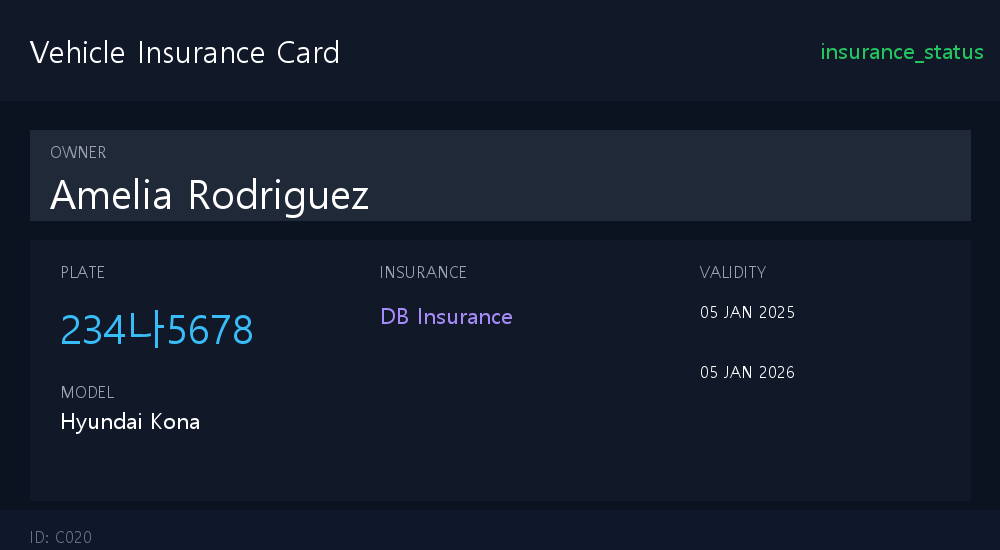

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super

In [20]:
create_vehicle_card('C020')